In [1]:
import polars as pl
import polars_corpus as plc

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
brown = pl.read_parquet("brown.parquet")

[Text(0.5, 1.0, 'sdfsdf')]

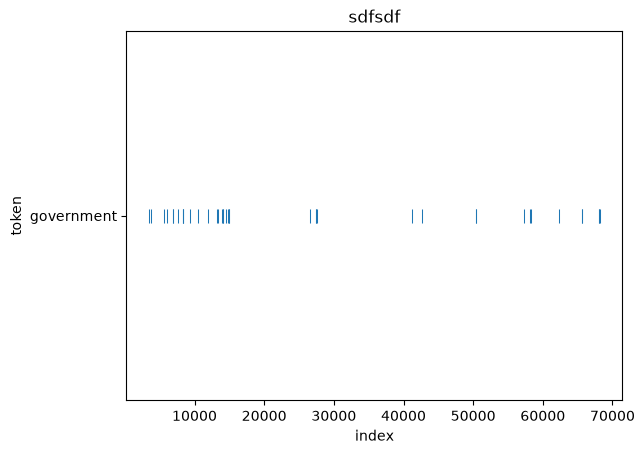

In [6]:
plc.barcode_plot(brown.filter(pl.col('category')=='government'), "token", 'government', size=10).set(title="sdfsdf")

In [120]:
import seaborn as sns
from matplotlib.axes import Axes
from polars_corpus._typing import IntoExpr, T_Frame
from polars_corpus.utils import (
    as_corpus,
    as_expr,
    check_choice,
    check_columns,
    check_expr,
    collect_like,
)

__all__ = ["dispersion_plot"]


def dispersion_plot(
    corpus: T_Frame,
    expr: IntoExpr,
    target: str,
    file_id_column: str = "file_id",
    relative: bool = True,
    linewidth: float = 0.75,
    size: float = 20,
    jitter: float | bool = 0,
    **kwargs,
) -> Axes:
    term = as_expr(expr)
    lf = as_corpus(corpus)

    if relative:
        data = lf.with_columns(    (pl.int_range(1, pl.len() + 1) / pl.len())      .over(file_id_column)      .alias("index")    )
    else:
        data = lf.with_columns(    pl.int_range(1, pl.len() + 1)      .over(file_id_column)      .alias("index")    )
    data = data.select("index", file_id_column, expr).filter(term==target).collect()

    ax= sns.stripplot(
        x="index",
        y=file_id_column,
        data=data,
        marker="|",
        linewidth=linewidth,
        size=size,
        jitter=jitter,
        **kwargs,
    )
    ax.set(xlabel="relative index" if relative else "index",
          title=f"Dispersion plot: {target}")
    return ax



[Text(0.5, 1.0, 'sdfsdf')]

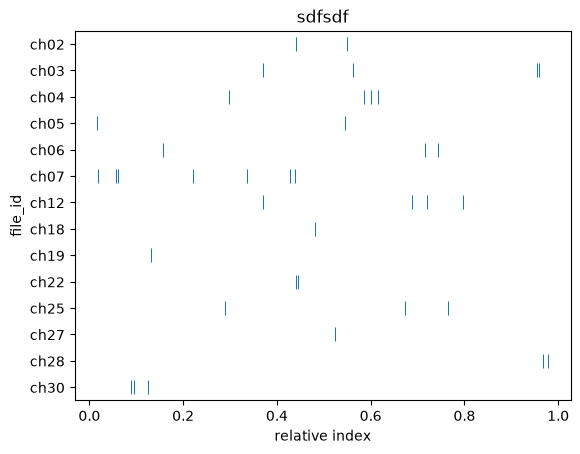

In [4]:
plc.dispersion_plot(brown.filter(pl.col('category')=='government'), "token", 'government', size=10, relative=True).set(title="sdfsdf")

In [93]:
brown['category'].unique()

category
str
"""mystery"""
"""learned"""
"""reviews"""
"""adventure"""
"""government"""
…
"""science_fiction"""
"""romance"""
"""news"""


In [76]:
brown

token,tag,sentence_tag,file_id,category
str,str,str,str,str
"""The""","""AT""","""B""","""ca01""","""news"""
"""Fulton""","""NP-TL""","""I""","""ca01""","""news"""
"""County""","""NN-TL""","""I""","""ca01""","""news"""
"""Grand""","""JJ-TL""","""I""","""ca01""","""news"""
"""Jury""","""NN-TL""","""I""","""ca01""","""news"""
…,…,…,…,…
"""boucle""","""NN""","""I""","""cr09""","""humor"""
"""dress""","""NN""","""I""","""cr09""","""humor"""
"""was""","""BEDZ""","""I""","""cr09""","""humor"""


In [44]:
df = df.collect()

In [45]:
df

token,freq,range,D,DP,DA
str,u32,u32,f64,f64,f64
"""underbracing""",1,1,0.0,0.009999,0.0
"""Arms""",6,6,0.602195,0.06,0.050505
"""lawsuit""",1,1,0.0,0.009999,0.0
"""Prosopopoeia""",1,1,0.0,0.01,0.0
"""distribute""",6,6,0.602195,0.06,0.050504
…,…,…,…,…,…
"""castles""",3,3,0.428511,0.029999,0.020201
"""Hundreds""",3,3,0.428511,0.029999,0.020201
"""lifters""",4,1,0.0,0.01,0.0


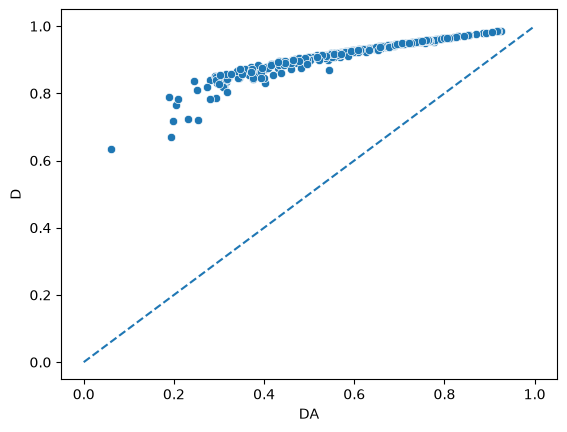

In [46]:
sns.scatterplot(x='DA', y='D', data=df.filter(pl.col('freq')>250))
plt.plot([0, 1], [0, 1], ls='--')

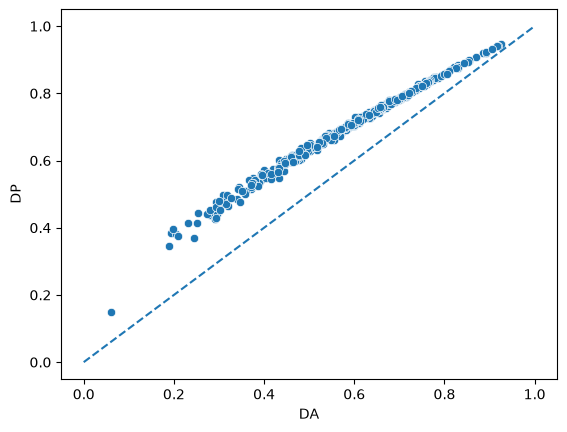

In [47]:
sns.scatterplot(x='DA', y='DP', data=df.filter(pl.col('freq')>250))
plt.plot([0, 1], [0, 1], ls='--')

In [ ]:
|